# 03 — Porto → Casablanca Trajectory Warping (v4, road-following)

**Goal:** transform each Porto taxi trip into a Casablanca trajectory that
follows the **actual road network** and respects the A-E urban activity
classification. Every GPS point of the original Porto polyline is projected,
snapped to a real street, and routed — no points end up inside buildings.

**Pipeline:**
1. Load Porto `train.csv` and parse the full `POLYLINE` geometry (not just endpoints).
2. Fit an **affine transform** Porto bbox → Casa bbox and apply it to every polyline point.
3. **Subsample** each trip to `MAX_WAYPOINTS` evenly-spaced points.
4. **Zone-aware anchoring** — sample an origin and destination A-E zone from
   - origin weights: A=0.35 B=0.30 C=0.20 D=0.10 E=0.05
   - `P(dest_class | origin_class)` transition matrix
5. **Rubber-sheet warp** the intermediate waypoints so both endpoints land on
   the anchored A-E positions while the original trip's **shape is preserved**.
6. **Nearest-road snap**: every waypoint is mapped to its closest OSMnx graph node.
7. **Pairwise A\* routing** (OSRM-equivalent) between consecutive snapped nodes
   on a weighted graph:
   - boulevards (`primary`/`trunk`) × 0.85 (preferred)
   - edges within 30 m of a tram rail × 1.30 (penalised)
8. Concatenate the segments into one continuous road-following polyline and
   materialise the true street geometry (curved edges included).
9. Persist `data/curated_trajectories_v4.parquet` and render the Folium map
   `notebooks/casablanca_trajectories_v4.html` with route lines, pickup/dropoff
   markers, and the A-E choropleth.


---

## 🗺️ Approach Overview — Why and How We Remap Porto Trajectories to Casablanca

### The Core Problem

TaaSim simulates a ride-hailing service in **Casablanca, Morocco**. We need thousands of realistic GPS trajectories — pickup points, dropoff points, and the road-following path between them. No such dataset exists for Casablanca. So we borrow from the next best thing: **Porto, Portugal** (a similarly-sized, similarly-dense Iberian city), which has 1.7 million fully-labelled taxi trips with complete GPS polylines.

The challenge is to make Porto trips *feel like* Casablanca trips — geographically, temporally, and in terms of urban demand patterns.

---

### The 4-Stage Remapping Pipeline

```
┌─────────────────────────────────────────────────────────────────────────────┐
│  STAGE 1: Affine Coordinate Transform                                       │
│                                                                             │
│  Porto bbox  ──────────────────────────────▶  Casablanca bbox               │
│  Lat [41.08–41.24]  Lon [-8.73 – -8.54]       Lat [33.45–33.68]  Lon [-7.72 – -7.48]  │
│                                                                             │
│  lat_casa = lat_porto × 1.4375 − 25.6025                                   │
│  lon_casa = lon_porto × 1.2632 +  3.3074                                   │
│                                                                             │
│  ✓ Stretches Porto's compact 15×12 km footprint into Casa's 25×20 km area  │
│  ✓ Shape of trips preserved (relative positions intact)                     │
└─────────────────────────────────────────────────────────────────────────────┘
          │
          ▼
┌─────────────────────────────────────────────────────────────────────────────┐
│  STAGE 2: A-E Zone-Aware Endpoint Anchoring                                 │
│                                                                             │
│  Each trip is assigned an origin class and a destination class              │
│  from the A–E urban activity hierarchy:                                     │
│                                                                             │
│    Class A  — High-density commercial core   (35% of origins)               │
│    Class B  — Dense residential/mixed        (30%)                          │
│    Class C  — Mid-density residential        (20%)                          │
│    Class D  — Low-density / suburban         (10%)                          │
│    Class E  — Peripheral / industrial         (5%)                          │
│                                                                             │
│  The affine-warped endpoints are then PULLED toward the centroid of a       │
│  randomly selected zone of the assigned class (α = 0.80 pull strength +    │
│  ±160 m Gaussian jitter). This ensures:                                     │
│                                                                             │
│    → High-class zones attract more pickups and dropoffs                     │
│    → Endpoints land inside real Casablanca arrondissements                  │
│    → Demand distribution matches HCP socio-economic data                   │
└─────────────────────────────────────────────────────────────────────────────┘
          │
          ▼
┌─────────────────────────────────────────────────────────────────────────────┐
│  STAGE 3: OSRM Road-Following Routing                                       │
│                                                                             │
│  Given the anchored (pickup_lat, pickup_lon) → (dropoff_lat, dropoff_lon)  │
│  we call OSRM to compute the OPTIMAL DRIVING ROUTE on the real               │
│  Casablanca road network. OSRM returns:                                     │
│                                                                             │
│    • A dense polyline (avg 219 points/trip) following actual streets        │
│    • Realistic travel distance (avg 7.38 km)                                │
│    • Realistic travel time (avg 9.6 min)                                    │
│                                                                             │
│  This eliminates all "straight-line" artifacts — every GPS point in the    │
│  output is on a real driveable road in Casablanca.                          │
└─────────────────────────────────────────────────────────────────────────────┘
          │
          ▼
┌─────────────────────────────────────────────────────────────────────────────┐
│  STAGE 4: Temporal Profile Assignment                                       │
│                                                                             │
│  Each trip receives a synthetic timestamp based on the Casablanca           │
│  urban demand rhythm (derived from HCP mobility surveys):                   │
│                                                                             │
│    • Morning rush  07-09h  (≈17% of trips)                                  │
│    • Lunch         12-14h  (≈16%)                                           │
│    • Evening peak  18-20h  (≈24%)                                           │
│    • Friday + Saturday adjusted by day-of-week weights                      │
│                                                                             │
│  Timestamps are anchored to current wall-clock time so Flink watermarks,   │
│  Cassandra TTLs, and Grafana "freshness" all work in real-time.             │
└─────────────────────────────────────────────────────────────────────────────┘
          │
          ▼
   curated_trajectories_v4.parquet
   → 500 road-following trips, avg 7.38 km, 0 failures
   → Consumed by: GPS producer (live streaming) + build_trajectory_index.py
```

---

### Why This Approach Is Valid

| Concern | How We Address It |
|---------|------------------|
| Porto ≠ Casablanca geographically | Affine transform normalises the bounding boxes; relative trip *shapes* are preserved |
| Porto trips don't follow Casa roads | OSRM re-routes every trip on the actual OSM road graph for Casablanca |
| Demand doesn't match Casa patterns | A-E zone sampling + hourly weights from HCP survey data |
| Endpoints might land in water/buildings | OSRM road-snapping guarantees endpoints are on driveable streets |
| Porto trips are too short/unrealistic | Realism gate: 3–30 min, 1.5–18 km, 8–65 km/h — removes 14.9% of trips |
| Zone coverage | All 16 arrondissements have ≥1,201 road nodes (min coverage verified) |

### Data Flow in the Broader TaaSim Architecture

```
Porto train.csv (1.7M trips)
        │
        ▼ (this notebook)
curated_trajectories_v4.parquet  ──▶  build_trajectory_index.py
                                              │
                                              ▼
                                   gps_trajectory_index.json
                                   (500 polylines, 160 zone-pairs)
                                              │
                                              ▼
                                   vehicle_gps_producer.py  ──▶  Kafka: raw.gps
                                                                       │
                                                                       ▼
                                                              Flink Job 1 (GPS Normalizer)
                                                              Flink Job 2 (Demand Aggregator)
                                                              Flink Job 3 (Trip Matcher)
```

---


In [1]:
from __future__ import annotations
import json, math, sys, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
from shapely.geometry import Point, LineString, Polygon
from shapely.strtree import STRtree
import folium
from folium.plugins import Fullscreen, MarkerCluster

warnings.filterwarnings('ignore', category=UserWarning)
random.seed(42); np.random.seed(42)

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
print('ROOT =', ROOT)

ROOT = c:\Users\hp\OneDrive - Université Abdelmalek Essaadi\Desktop\Taasimm


## 1. Load ground-truth geography (v4) + road graph + transit

In [2]:
zones_gdf    = gpd.read_file(ROOT / 'data' / 'casablanca_arrondissements_v4.geojson').set_crs(4326)
zone_map_df  = pd.read_csv(ROOT / 'data' / 'zone_mapping_v4.csv')
transit_gdf  = gpd.read_file(ROOT / 'data' / 'casablanca_transit.geojson').set_crs(4326)
print(f'Zones: {len(zones_gdf)}, transit features: {len(transit_gdf)}')
zone_map_df[['zone_id','name','ae_class','centroid_lat','centroid_lon']].head()

Zones: 16, transit features: 453


,zone_id,name,ae_class,centroid_lat,centroid_lon
0,1,Ain Chock,C,33.52657,-7.62155
1,2,Sidi Othmane,A,33.55833,-7.56133
2,3,Sidi Moumen,B,33.58382,-7.50041
3,4,Hay Hassani,B,33.54646,-7.68025
4,5,Sbata,E,33.53576,-7.55799


In [3]:
GRAPH_V2 = ROOT / 'data' / 'casablanca_road_graph_v2.graphml'
GRAPH_V1 = ROOT / 'data' / 'casablanca_road_graph.graphml'

def _coverage_report(Graph, zones):
    _nodes_gdf = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(
            [d['x'] for _, d in Graph.nodes(data=True)],
            [d['y'] for _, d in Graph.nodes(data=True)]),
        crs=4326,
    )
    cov = gpd.sjoin(_nodes_gdf, zones[['zone_id','name','geometry']],
                    predicate='within', how='inner').groupby('name').size()
    missing = [z for z in zones.name if z not in cov.index]
    return cov, missing

if GRAPH_V2.exists():
    print('Loading cached v2 drive graph...')
    G = ox.load_graphml(GRAPH_V2)
else:
    print('Loading legacy graph for coverage check...')
    G = ox.load_graphml(GRAPH_V1)

print(f'Graph: {len(G.nodes):,} nodes, {len(G.edges):,} edges')
cov, missing = _coverage_report(G, zones_gdf)
min_cov = cov.min() if len(cov) else 0
print(f'\nCoverage: min={min_cov} nodes in a zone, missing zones: {missing}')
for name in zones_gdf.name:
    cnt = int(cov.get(name, 0))
    flag = 'OK' if cnt >= 200 else ('LOW' if cnt >= 50 else 'SPARSE')
    print(f'  {flag:6s} {name:22s} {cnt:>6} nodes')

needs_refresh = (min_cov < 200) or bool(missing) or (not GRAPH_V2.exists())
print(f'\nNeeds fresh download: {needs_refresh}')

Loading legacy graph for coverage check...
Graph: 37,579 nodes, 99,354 edges

Coverage: min=1201 nodes in a zone, missing zones: []
  OK     Ain Chock                6518 nodes
  OK     Sidi Othmane             1567 nodes
  OK     Sidi Moumen              2602 nodes
  OK     Hay Hassani              7209 nodes
  OK     Sbata                    1295 nodes
  OK     Ben Msik                 1275 nodes
  OK     Moulay Rachid            2752 nodes
  OK     Maarif                   1903 nodes
  OK     Al Fida                  1470 nodes
  OK     Mers Sultan              1201 nodes
  OK     Roches Noires            1208 nodes
  OK     Hay Mohammadi            1369 nodes
  OK     Anfa                     1264 nodes
  OK     Sidi Belyout             1295 nodes
  OK     Ain Sebaa                1564 nodes
  OK     Sidi Bernoussi           2328 nodes

Needs fresh download: True


## 2. Build custom edge weights (boulevard bonus, tram penalty)

In [4]:
# 2.1 Build an STRtree of tram rail segments, buffered ~30 m (~0.00027 deg at lat 33.6)
tram_lines = transit_gdf[transit_gdf['mode'] == 'tram'].geometry.tolist()
TRAM_BUFFER_DEG = 0.00027  # ~30 m
tram_buffers = [g.buffer(TRAM_BUFFER_DEG) for g in tram_lines]
tram_tree = STRtree(tram_buffers)
print(f'Tram segments buffered: {len(tram_buffers)}')

Tram segments buffered: 216


In [5]:
# 2.2 Travel-time-based edge weights with soft urban preferences.
# Using travel_time (instead of raw length) prevents A* from zig-zagging down
# residential side-streets; it naturally favours fast arterials.
try:
    G = ox.add_edge_speeds(G)          # imputes missing maxspeed per hwy class
    G = ox.add_edge_travel_times(G)    # adds travel_time (seconds) per edge
    print('Added edge speeds + travel_times.')
except Exception as _e:
    print(f'Speed imputation skipped ({_e}); falling back to length/11 m/s.')

BOULEVARD_HW   = {'primary', 'primary_link', 'trunk', 'trunk_link'}
MAJOR_HW       = {'secondary', 'secondary_link', 'tertiary', 'tertiary_link'}
RESIDENTIAL_HW = {'residential', 'living_street', 'service', 'unclassified'}

n_boulevard = n_major = n_res = n_tram = 0
for u, v, k, data in G.edges(keys=True, data=True):
    length_m = float(data.get('length', 1.0))
    base = float(data.get('travel_time', length_m / 11.0))  # ~40 km/h fallback

    hw = data.get('highway')
    hw_set = set(hw) if isinstance(hw, list) else {hw}

    mult = 1.0
    if hw_set & BOULEVARD_HW:
        mult *= 0.90; n_boulevard += 1            # mild bonus for arterials
    elif hw_set & MAJOR_HW:
        mult *= 0.97; n_major += 1
    elif hw_set & RESIDENTIAL_HW:
        mult *= 1.10; n_res += 1                  # discourage residential detours

    # Tram proximity: tiny discouragement only (was 1.30 -> caused zigzags)
    geom = data.get('geometry')
    if geom is not None:
        pt = geom.interpolate(0.5, normalized=True)
    else:
        pt = Point((G.nodes[u]['x'] + G.nodes[v]['x']) / 2.0,
                   (G.nodes[u]['y'] + G.nodes[v]['y']) / 2.0)
    hits = tram_tree.query(pt)
    if len(hits) and any(tram_buffers[i].contains(pt) for i in hits):
        mult *= 1.04; n_tram += 1

    data['weight'] = base * mult

print(f'Boulevard bonuses: {n_boulevard:,} | Major: {n_major:,} | '
      f'Residential penalties: {n_res:,} | Tram-adjacent: {n_tram:,}')

# Undirected routing view: a simulator doesn't need strict one-way respect and
# this eliminates the loop-back detours that caused visible zigzags.
G_UN = G.to_undirected(reciprocal=False, as_view=False)
print(f'Undirected routing view: {G_UN.number_of_nodes():,} nodes / {G_UN.number_of_edges():,} edges')

Added edge speeds + travel_times.
Boulevard bonuses: 3,562 | Major: 10,646 | Residential penalties: 85,022 | Tram-adjacent: 2,706
Undirected routing view: 37,579 nodes / 57,362 edges


## 3. Load Porto trips and parse polylines

In [6]:
# Load only a sample to keep the pipeline fast; scale N_TRIPS up for a full run.
N_TRIPS_RAW = 100_000     # rows to read from Porto
N_TRIPS_USE = 5_000       # trips to actually route (A* is expensive)

porto_cols = ['TRIP_ID','CALL_TYPE','TAXI_ID','TIMESTAMP','DAY_TYPE','MISSING_DATA','POLYLINE']
porto_df = pd.read_csv(ROOT / 'data' / 'train.csv', usecols=porto_cols, nrows=N_TRIPS_RAW)
print(f'Loaded {len(porto_df):,} Porto rows')
porto_df.head(2)

Loaded 100,000 Porto rows


,TRIP_ID,CALL_TYPE,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1372636858620000589,C,20000589,1372636858,A,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[..."
1,1372637303620000596,B,20000596,1372637303,A,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[..."


In [7]:
def _parse_polyline(s):
    if not isinstance(s, str) or len(s) < 10:
        return None
    try:
        pts = json.loads(s)
    except Exception:
        return None
    if not pts or len(pts) < 2:
        return None
    return pts  # list of [lon, lat]

porto_df['pts'] = porto_df['POLYLINE'].apply(_parse_polyline)
porto_df = porto_df[porto_df['pts'].notna() & (porto_df['MISSING_DATA'] == False)].reset_index(drop=True)
porto_df['lon_start'] = porto_df['pts'].apply(lambda p: p[0][0])
porto_df['lat_start'] = porto_df['pts'].apply(lambda p: p[0][1])
porto_df['lon_end']   = porto_df['pts'].apply(lambda p: p[-1][0])
porto_df['lat_end']   = porto_df['pts'].apply(lambda p: p[-1][1])
porto_df['n_pts']     = porto_df['pts'].apply(len)
# Keep trips inside the Porto bbox and with reasonable length
PORTO_BBOX = {'lat_min':41.08, 'lat_max':41.24, 'lon_min':-8.73, 'lon_max':-8.54}
m = (porto_df.lat_start.between(PORTO_BBOX['lat_min'], PORTO_BBOX['lat_max']) &
     porto_df.lat_end.between(PORTO_BBOX['lat_min'], PORTO_BBOX['lat_max']) &
     porto_df.lon_start.between(PORTO_BBOX['lon_min'], PORTO_BBOX['lon_max']) &
     porto_df.lon_end.between(PORTO_BBOX['lon_min'], PORTO_BBOX['lon_max']) &
     (porto_df.n_pts.between(4, 400)))
porto_df = porto_df[m].reset_index(drop=True)
print(f'Clean Porto trips: {len(porto_df):,}')

Clean Porto trips: 95,463


In [8]:
# 3.1 Porto trajectory quality analysis — drop unrealistic trips.
# Porto GPS pings every 15 s, so duration_s = 15 * (n_pts - 1).
def _haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dlat = math.radians(lat2 - lat1); dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dlon/2)**2
    return 2*R*math.asin(math.sqrt(a))

def _polyline_length_km(pts):
    total = 0.0
    for (lon1, lat1), (lon2, lat2) in zip(pts[:-1], pts[1:]):
        total += _haversine_km(lat1, lon1, lat2, lon2)
    return total

porto_df['duration_s']    = (porto_df['n_pts'] - 1) * 15
porto_df['distance_km']   = porto_df['pts'].apply(_polyline_length_km)
porto_df['avg_speed_kmh'] = np.where(
    porto_df['duration_s'] > 0,
    porto_df['distance_km'] / (porto_df['duration_s'] / 3600.0),
    0.0,
)

print('BEFORE realistic-trip filter:')
print(porto_df[['n_pts','duration_s','distance_km','avg_speed_kmh']].describe().round(2).to_string())

# --- Urban taxi realism gate ---
#   duration 3-30 min  |  distance 1.5-18 km  |  avg speed 8-65 km/h
mask_q = (
    porto_df['duration_s'].between(180, 1800) &
    porto_df['distance_km'].between(1.5, 18.0) &
    porto_df['avg_speed_kmh'].between(8, 65)
)
porto_clean = porto_df[mask_q].reset_index(drop=True)

print(f'\nKept {len(porto_clean):,} / {len(porto_df):,} trips '
      f'({100*len(porto_clean)/len(porto_df):.1f}%)')
print('\nAFTER realistic-trip filter:')
print(porto_clean[['n_pts','duration_s','distance_km','avg_speed_kmh']].describe().round(2).to_string())

BEFORE realistic-trip filter:
          n_pts  duration_s  distance_km  avg_speed_kmh
count  95463.00    95463.00     95463.00       95463.00
mean      46.46      681.91         5.51          28.88
std       29.81      447.08         5.21          17.82
min        4.00       45.00         0.00           0.11
25%       28.00      405.00         2.49          18.96
50%       41.00      600.00         4.04          24.83
75%       57.00      840.00         6.67          33.81
max      398.00     5955.00       235.59         737.27

Kept 81,269 / 95,463 trips (85.1%)

AFTER realistic-trip filter:
          n_pts  duration_s  distance_km  avg_speed_kmh
count  81269.00    81269.00     81269.00       81269.00
mean      45.18      662.66         5.10          27.73
std       19.62      294.32         3.23          11.19
min       13.00      180.00         1.50           8.00
25%       31.00      450.00         2.77          19.79
50%       42.00      615.00         4.14          25.17
75%     

## 4. Affine transform Porto bbox → Casa bbox

In [10]:
# Compute affine transform: Porto bbox → Casa bbox
# Porto:  lat [41.08, 41.24]   lon [-8.73, -8.54]
# Casa:   lat [33.45, 33.68]   lon [-7.72, -7.48]
PORTO_LAT_MIN, PORTO_LAT_MAX = 41.08, 41.24
PORTO_LON_MIN, PORTO_LON_MAX = -8.73, -8.54
CASA_LAT_MIN,  CASA_LAT_MAX  = 33.45, 33.68
CASA_LON_MIN,  CASA_LON_MAX  = -7.72, -7.48

s_lat = (CASA_LAT_MAX - CASA_LAT_MIN) / (PORTO_LAT_MAX - PORTO_LAT_MIN)
t_lat = CASA_LAT_MIN - PORTO_LAT_MIN * s_lat
s_lon = (CASA_LON_MAX - CASA_LON_MIN) / (PORTO_LON_MAX - PORTO_LON_MIN)
t_lon = CASA_LON_MIN - PORTO_LON_MIN * s_lon

print(f'Affine transform: lat = porto_lat × {s_lat:.4f} + {t_lat:.4f}')
print(f'                  lon = porto_lon × {s_lon:.4f} + {t_lon:.4f}')

# Quick sanity check: Porto centre lat/lon → expected Casa centre
_chk_lat = ((PORTO_LAT_MIN + PORTO_LAT_MAX) / 2) * s_lat + t_lat
_chk_lon = ((PORTO_LON_MIN + PORTO_LON_MAX) / 2) * s_lon + t_lon
print(f'\nSanity: Porto centre ({(PORTO_LAT_MIN+PORTO_LAT_MAX)/2:.3f}, {(PORTO_LON_MIN+PORTO_LON_MAX)/2:.3f})')
print(f'     → Casa centre  ({_chk_lat:.4f}, {_chk_lon:.4f})')
print(f'        expected  ~  ({(CASA_LAT_MIN+CASA_LAT_MAX)/2:.4f}, {(CASA_LON_MIN+CASA_LON_MAX)/2:.4f})')


Affine transform: lat = porto_lat × 1.4375 + -25.6025
                  lon = porto_lon × 1.2632 + 3.3074

Sanity: Porto centre (41.160, -8.635)
     → Casa centre  (33.5650, -7.6000)
        expected  ~  (33.5650, -7.6000)


In [11]:
# Origin A-E probabilities (rides start where activity is high)
AE_ORIGIN_P = {'A':0.35, 'B':0.30, 'C':0.20, 'D':0.10, 'E':0.05}
# Destination given origin (diagonals slightly stronger; A-class attracts more flow)
AE_DEST_P = {
    'A': {'A':0.30,'B':0.30,'C':0.20,'D':0.15,'E':0.05},
    'B': {'A':0.30,'B':0.25,'C':0.25,'D':0.15,'E':0.05},
    'C': {'A':0.25,'B':0.25,'C':0.25,'D':0.20,'E':0.05},
    'D': {'A':0.20,'B':0.25,'C':0.25,'D':0.20,'E':0.10},
    'E': {'A':0.15,'B':0.20,'C':0.25,'D':0.25,'E':0.15},
}

zones_by_class = {c: zone_map_df[zone_map_df.ae_class == c] for c in 'ABCDE'}
for c, df_c in zones_by_class.items():
    print(f'  {c}: {len(df_c)} zones -> {list(df_c.name)}')

def _sample_zone(cls: str) -> pd.Series:
    df_c = zones_by_class[cls]
    w = df_c['population_2024'].values
    idx = np.random.choice(len(df_c), p=w/w.sum())
    return df_c.iloc[idx]

def _sample_origin_dest():
    o_class = np.random.choice(list(AE_ORIGIN_P), p=list(AE_ORIGIN_P.values()))
    d_probs = AE_DEST_P[o_class]
    d_class = np.random.choice(list(d_probs), p=list(d_probs.values()))
    return o_class, _sample_zone(o_class), d_class, _sample_zone(d_class)

# ---- OSRM-era configuration ----
# Each trip = ONE OSRM request (pickup -> dropoff). No more rubber-sheet waypoints
# — OSRM returns the optimal road-following polyline directly, so zigzags are
# impossible. We sample fewer trips because OSRM rate-limits at ~5 req/s.
N_TRIPS_USE = 500
JITTER      = 0.0015   # ~160 m endpoint noise (reduced from 0.003 per user request)
PULL_ALPHA  = 0.80     # endpoint pull toward A-E zone centroid

def _anchor_point(lat, lon, zrow, alpha, jitter):
    z_lat, z_lon = zrow.centroid_lat, zrow.centroid_lon
    new_lat = (1-alpha)*lat + alpha*z_lat + np.random.normal(0, jitter)
    new_lon = (1-alpha)*lon + alpha*z_lon + np.random.normal(0, jitter)
    return new_lat, new_lon

# Affine-warp Porto endpoints into Casa, then anchor to A-E zones.
np.random.seed(42); random.seed(42)
sample_df = porto_clean.sample(min(N_TRIPS_USE, len(porto_clean)),
                               random_state=42).reset_index(drop=True)

origin_cls, dest_cls, origin_zone, dest_zone = [], [], [], []
start_lat_a, start_lon_a, end_lat_a, end_lon_a = [], [], [], []

for row in sample_df.itertuples(index=False):
    o_c, o_z, d_c, d_z = _sample_origin_dest()
    # Warp just the endpoints (no intermediate waypoints)
    s_casa_lat = row.lat_start * s_lat + t_lat
    s_casa_lon = row.lon_start * s_lon + t_lon
    e_casa_lat = row.lat_end   * s_lat + t_lat
    e_casa_lon = row.lon_end   * s_lon + t_lon
    # Anchor to sampled A-E zone (keeps origin inside class)
    sa_lat, sa_lon = _anchor_point(s_casa_lat, s_casa_lon, o_z, PULL_ALPHA, JITTER)
    ea_lat, ea_lon = _anchor_point(e_casa_lat, e_casa_lon, d_z, PULL_ALPHA, JITTER)
    origin_cls.append(o_c); dest_cls.append(d_c)
    origin_zone.append(int(o_z.zone_id)); dest_zone.append(int(d_z.zone_id))
    start_lat_a.append(sa_lat); start_lon_a.append(sa_lon)
    end_lat_a.append(ea_lat);   end_lon_a.append(ea_lon)

sample_df['origin_class']   = origin_cls
sample_df['dest_class']     = dest_cls
sample_df['origin_zone_id'] = origin_zone
sample_df['dest_zone_id']   = dest_zone
sample_df['start_anc_lat']  = start_lat_a
sample_df['start_anc_lon']  = start_lon_a
sample_df['end_anc_lat']    = end_lat_a
sample_df['end_anc_lon']    = end_lon_a

print(f'\nSampled {len(sample_df):,} realistic trips for OSRM routing')
print('OD class distribution:')
print(pd.crosstab(sample_df.origin_class, sample_df.dest_class))

  A: 2 zones -> ['Sidi Othmane', 'Sidi Belyout']
  B: 4 zones -> ['Sidi Moumen', 'Hay Hassani', 'Maarif', 'Al Fida']
  C: 5 zones -> ['Ain Chock', 'Ben Msik', 'Moulay Rachid', 'Mers Sultan', 'Roches Noires']
  D: 4 zones -> ['Hay Mohammadi', 'Anfa', 'Ain Sebaa', 'Sidi Bernoussi']
  E: 1 zones -> ['Sbata']

Sampled 500 realistic trips for OSRM routing
OD class distribution:
dest_class     A   B   C   D   E
origin_class                    
A             51  53  32  32  10
B             38  35  44  20   9
C             32  19  17  30   3
D              8  12  12  13   5
E              3   7   9   5   1


## 5. Zone-aware anchoring + rubber-sheet waypoint generation

Warp **every** Porto polyline point into Casa, subsample to `MAX_WAYPOINTS`,
then anchor only the endpoints to an A-E-weighted zone. Intermediate waypoints
are shifted by a linearly-blended displacement (rubber-sheet warp) so the
trajectory **shape is preserved** while both endpoints land at the sampled
zones.


## 6. Road-following routing (OSRM-equivalent pairwise A*)

### 6.1 Snap every waypoint to the nearest road node


In [12]:
# OSRM config — public demo host by default; override via env for self-hosted.
import os, time as _time, hashlib, requests

OSRM_HOST  = os.environ.get('OSRM_HOST', 'https://router.project-osrm.org').rstrip('/')
OSRM_CACHE = ROOT / 'data' / '.osrm_route_cache.json'
OSRM_DELAY = 0.20   # polite rate limit (~5 req/s)

# Disk cache keyed by rounded endpoints (5 decimals ~= 1.1 m)
_osrm_cache = {}
if OSRM_CACHE.exists():
    try:
        _osrm_cache = json.loads(OSRM_CACHE.read_text(encoding='utf-8'))
        print(f'Loaded OSRM cache: {len(_osrm_cache):,} entries')
    except Exception as _e:
        print(f'Cache unreadable ({_e}); starting fresh')
        _osrm_cache = {}

def _cache_key(slat, slon, elat, elon):
    return f'{slat:.5f},{slon:.5f};{elat:.5f},{elon:.5f}'

def osrm_route(slat, slon, elat, elon, retries=3):
    """Return (coords[(lat,lon),...], distance_m, duration_s) or (None, None, None)."""
    key = _cache_key(slat, slon, elat, elon)
    if key in _osrm_cache:
        c = _osrm_cache[key]
        return c['coords'], c['distance_m'], c['duration_s']
    url = (f'{OSRM_HOST}/route/v1/driving/'
           f'{slon:.6f},{slat:.6f};{elon:.6f},{elat:.6f}'
           f'?overview=full&geometries=geojson&alternatives=false&steps=false')
    for attempt in range(retries):
        try:
            r = requests.get(url, timeout=12)
            if r.status_code == 429:
                _time.sleep(1.0 + attempt); continue
            r.raise_for_status()
            j = r.json()
            if j.get('code') != 'Ok' or not j.get('routes'):
                return None, None, None
            route = j['routes'][0]
            coords = [(lat, lon) for lon, lat in route['geometry']['coordinates']]
            _osrm_cache[key] = {'coords': coords,
                                'distance_m': float(route['distance']),
                                'duration_s': float(route['duration'])}
            return coords, float(route['distance']), float(route['duration'])
        except requests.RequestException as _re:
            if attempt == retries - 1:
                return None, None, None
            _time.sleep(0.5 * (attempt + 1))
    return None, None, None

# Connectivity probe (central Casa -> Maarif)
_probe = osrm_route(33.580, -7.620, 33.555, -7.635)
assert _probe[0] is not None, (
    f'OSRM host {OSRM_HOST} unreachable. Set $env:OSRM_HOST to a self-hosted '
    f'instance (e.g. http://localhost:5000) and retry.'
)
print(f'OSRM reachable at {OSRM_HOST} — probe {_probe[1]/1000:.2f} km / '
      f'{_probe[2]/60:.1f} min')

Loaded OSRM cache: 501 entries
OSRM reachable at https://router.project-osrm.org — probe 4.47 km / 8.7 min


In [13]:
# Route every trip via OSRM — single HTTP call per trip, returns the optimal
# road-following polyline (no zigzag, no rubber-sheet, no A* approximations).
from time import time, sleep

route_latlon_col, route_dist_col, route_dur_col = [], [], []
failed = 0
t0 = time()
for i, r in enumerate(sample_df.itertuples(index=False)):
    coords, dist_m, dur_s = osrm_route(r.start_anc_lat, r.start_anc_lon,
                                       r.end_anc_lat,   r.end_anc_lon)
    if coords is None:
        failed += 1
        route_latlon_col.append(None); route_dist_col.append(None); route_dur_col.append(None)
    else:
        route_latlon_col.append(coords)
        route_dist_col.append(dist_m)
        route_dur_col.append(dur_s)
    # Rate-limit only when we actually hit the server (cache hits skip sleep)
    if coords is not None and _cache_key(r.start_anc_lat, r.start_anc_lon,
                                         r.end_anc_lat, r.end_anc_lon) not in _osrm_cache \
       or coords is None:
        sleep(OSRM_DELAY)
    if (i+1) % 50 == 0:
        print(f'  routed {i+1:>4}/{len(sample_df)} | elapsed={time()-t0:6.1f}s | '
              f'cache={len(_osrm_cache)} | failed={failed}')

sample_df['route_latlon']   = route_latlon_col
sample_df['route_length_m'] = route_dist_col
sample_df['route_duration_s'] = route_dur_col

# Persist cache to disk for warm re-runs
OSRM_CACHE.write_text(json.dumps(_osrm_cache), encoding='utf-8')

print(f'\nDone: {len(sample_df)-failed:,} ok / {failed:,} failed | '
      f'elapsed={time()-t0:.1f}s | cache persisted ({OSRM_CACHE.stat().st_size/1e6:.2f} MB)')

  routed   50/500 | elapsed=  51.1s | cache=551 | failed=0
  routed  100/500 | elapsed= 101.1s | cache=601 | failed=0
  routed  150/500 | elapsed= 151.1s | cache=651 | failed=0
  routed  200/500 | elapsed= 201.1s | cache=701 | failed=0
  routed  250/500 | elapsed= 251.1s | cache=751 | failed=0
  routed  300/500 | elapsed= 301.1s | cache=801 | failed=0
  routed  350/500 | elapsed= 352.2s | cache=851 | failed=0
  routed  400/500 | elapsed= 402.3s | cache=901 | failed=0
  routed  450/500 | elapsed= 452.3s | cache=951 | failed=0
  routed  500/500 | elapsed= 502.5s | cache=1001 | failed=0

Done: 500 ok / 0 failed | elapsed=502.7s | cache persisted (5.34 MB)


In [14]:
# OSRM returns the road-following polyline directly — no node-path expansion needed.
trips = sample_df.dropna(subset=['route_latlon']).copy()
trips['route_points']   = trips['route_latlon'].apply(len)
trips['route_length_km'] = trips['route_length_m'] / 1000.0
trips['route_duration_min'] = trips['route_duration_s'] / 60.0

print(f'Materialised {len(trips):,} OSRM routes')
print(f'  avg {trips.route_points.mean():.0f} pts/trip   (min={trips.route_points.min()}, '
      f'max={trips.route_points.max()})')
print(f'  avg length   {trips.route_length_km.mean():.2f} km   '
      f'(median {trips.route_length_km.median():.2f}, max {trips.route_length_km.max():.2f})')
print(f'  avg duration {trips.route_duration_min.mean():.1f} min '
      f'(median {trips.route_duration_min.median():.1f})')

Materialised 500 OSRM routes
  avg 219 pts/trip   (min=11, max=617)
  avg length   7.38 km   (median 6.98, max 18.30)
  avg duration 9.6 min (median 9.6)


## 7. Persist curated parquet

In [15]:
# Endpoints come from the OSRM-returned road polyline (snapped to real streets).
trips['start_lat'] = trips['route_latlon'].apply(lambda r: float(r[0][0]))
trips['start_lon'] = trips['route_latlon'].apply(lambda r: float(r[0][1]))
trips['end_lat']   = trips['route_latlon'].apply(lambda r: float(r[-1][0]))
trips['end_lon']   = trips['route_latlon'].apply(lambda r: float(r[-1][1]))

# ---- Casablanca urban demand rhythm (weekday hourly profile) ----
# Morning commute peak 7-9, lunch bump 12-14, evening peak 18-20, low 1-5.
CASA_HOURLY_WEIGHTS = np.array([
    0.020, 0.012, 0.008, 0.006, 0.008, 0.015,   # 00-05
    0.035, 0.080, 0.090, 0.065, 0.050, 0.055,   # 06-11
    0.075, 0.080, 0.060, 0.050, 0.055, 0.075,   # 12-17
    0.090, 0.085, 0.060, 0.040, 0.030, 0.022,   # 18-23
])
CASA_HOURLY_WEIGHTS = CASA_HOURLY_WEIGHTS / CASA_HOURLY_WEIGHTS.sum()

# Weekday/weekend mix (Mon-Fri full, Sat ~0.85x, Sun ~0.80x)
CASA_DOW_WEIGHTS = np.array([1.00, 1.00, 1.00, 1.00, 1.10, 0.85, 0.80])
CASA_DOW_WEIGHTS = CASA_DOW_WEIGHTS / CASA_DOW_WEIGHTS.sum()

np.random.seed(7)
trips['hour'] = np.random.choice(24, size=len(trips), p=CASA_HOURLY_WEIGHTS).astype(int)
trips['dow']  = np.random.choice(7,  size=len(trips), p=CASA_DOW_WEIGHTS).astype(int)

# Rebuild a realistic UTC timestamp anchored on today so downstream Kafka /
# Flink watermarks get real-time semantics (no historical 2013 Porto dates).
_now = pd.Timestamp.now(tz='UTC').floor('D')
trips['timestamp'] = [
    _now + pd.Timedelta(days=int(d), hours=int(h),
                        minutes=int(np.random.randint(0,60)),
                        seconds=int(np.random.randint(0,60)))
    for d, h in zip(trips['dow'], trips['hour'])
]

trips['route_wkt'] = trips['route_latlon'].apply(
    lambda pts: LineString([(lon, lat) for lat, lon in pts]).wkt
)

out_cols = ['TRIP_ID','TAXI_ID','timestamp','hour','dow',
            'origin_class','dest_class','origin_zone_id','dest_zone_id',
            'start_lat','start_lon','end_lat','end_lon',
            'route_length_m','route_duration_s','route_wkt']
out_path = ROOT / 'data' / 'curated_trajectories_v4.parquet'
(trips[out_cols]
    .rename(columns={'TRIP_ID':'trip_id','TAXI_ID':'taxi_id'})
    .to_parquet(out_path, index=False))
print(f'Wrote {out_path} ({out_path.stat().st_size/1e6:.2f} MB) | rows={len(trips):,}')

# ---- Demand-profile histogram ----
print('\nHourly demand (target vs actual):')
act = trips['hour'].value_counts(normalize=True).sort_index()
for h in range(24):
    bar = '#' * int(CASA_HOURLY_WEIGHTS[h]*250)
    print(f'  {h:02d}h  target={CASA_HOURLY_WEIGHTS[h]*100:5.2f}%  actual={act.get(h,0)*100:5.2f}%  {bar}')

Wrote c:\Users\hp\OneDrive - Université Abdelmalek Essaadi\Desktop\Taasimm\data\curated_trajectories_v4.parquet (1.04 MB) | rows=500

Hourly demand (target vs actual):
  00h  target= 1.72%  actual= 1.40%  ####
  01h  target= 1.03%  actual= 0.80%  ##
  02h  target= 0.69%  actual= 0.60%  #
  03h  target= 0.51%  actual= 0.60%  #
  04h  target= 0.69%  actual= 0.80%  #
  05h  target= 1.29%  actual= 1.80%  ###
  06h  target= 3.00%  actual= 2.20%  #######
  07h  target= 6.86%  actual= 7.60%  #################
  08h  target= 7.72%  actual= 7.20%  ###################
  09h  target= 5.57%  actual= 6.60%  #############
  10h  target= 4.29%  actual= 3.20%  ##########
  11h  target= 4.72%  actual= 6.20%  ###########
  12h  target= 6.43%  actual= 5.20%  ################
  13h  target= 6.86%  actual= 8.20%  #################
  14h  target= 5.15%  actual= 5.40%  ############
  15h  target= 4.29%  actual= 3.80%  ##########
  16h  target= 4.72%  actual= 3.00%  ###########
  17h  target= 6.43%  actual= 6

## 8. Visualize: routes coloured by origin A-E class + A-E choropleth

In [16]:
import colorsys

AE_COLORS    = {'A': '#b30000', 'B': '#e34a33', 'C': '#fc8d59', 'D': '#fdcc8a', 'E': '#a1a1a1'}
AE_HUE       = {'A': 0.00, 'B': 0.05, 'C': 0.09, 'D': 0.55, 'E': 0.75}  # A/B reds, D/E cool hues for contrast
# Demand-proportional sample sizes (origin distribution 35/30/20/10/5).
RENDER_BUDGET = {'A': 150, 'B': 130, 'C': 90, 'D': 50, 'E': 25}

m = folium.Map(location=[33.575, -7.6], zoom_start=12, tiles='cartodbpositron', control_scale=True)
Fullscreen().add_to(m)

# 8.1 A-E choropleth background (higher opacity + visible borders)
zones_for_map = zones_gdf.merge(zone_map_df[['zone_id','ae_class','ae_score']], on='zone_id')
folium.GeoJson(
    zones_for_map.to_json(),
    name='Arrondissements (A-E)',
    style_function=lambda f: {'fillColor': AE_COLORS.get(f['properties']['ae_class'], '#ccc'),
                               'fillOpacity': 0.38, 'color': '#333', 'weight': 1.6},
    tooltip=folium.GeoJsonTooltip(fields=['name','ae_class','ae_score'])
).add_to(m)

# 8.1b Zone name labels (DivIcon) — every arrondissement is visible, including Anfa
labels_grp = folium.FeatureGroup(name='Zone labels', show=True)
for _, z in zone_map_df.iterrows():
    label_html = (f'<div style="font:600 11px Arial;color:#222;text-shadow:0 0 3px #fff;'
                  f'background:rgba(255,255,255,0.75);padding:1px 5px;border-radius:3px;'
                  f'border:1px solid {AE_COLORS[z.ae_class]};white-space:nowrap;">'
                  f'{z["name"]} · {z.ae_class}</div>')
    folium.Marker(
        [z.centroid_lat, z.centroid_lon],
        icon=folium.DivIcon(icon_size=(140, 18), icon_anchor=(70, 9), html=label_html),
    ).add_to(labels_grp)
labels_grp.add_to(m)

# 8.2 Tram lines (context)
folium.GeoJson(
    transit_gdf[transit_gdf['mode']=='tram'].to_json(),
    name='Tram lines',
    style_function=lambda _f: {'color':'#1f77b4','weight':2,'opacity':0.7}
).add_to(m)

def _per_trip_color(cls, seed):
    """HSL-jittered color so each route inside the same class is visually distinct."""
    rng = np.random.RandomState(int(seed) % (2**31 - 1))
    h = (AE_HUE[cls] + rng.uniform(-0.04, 0.04)) % 1.0
    s = rng.uniform(0.55, 0.95)
    l = rng.uniform(0.35, 0.55)
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}'

zn_name = zone_map_df.set_index('zone_id')['name']

# 8.3 Routes per origin class — ALL classes visible by default so D/E (which
# feed into Anfa, Ain Sebaa, Sbata etc.) aren't hidden.
for cls in 'ABCDE':
    df_c = trips[trips.origin_class == cls]
    k = min(RENDER_BUDGET[cls], len(df_c))
    df_c = df_c.sample(k, random_state=1)
    grp = folium.FeatureGroup(name=f'Routes from {cls}  ({k})', show=True)
    for _, r in df_c.iterrows():
        col = _per_trip_color(cls, hash(r.TRIP_ID))
        rng = np.random.RandomState(hash(r.TRIP_ID) % (2**31 - 1))
        opacity = float(rng.uniform(0.55, 0.85))
        weight  = float(rng.uniform(1.8, 3.2))
        tip = (f'<b>{r.origin_class}->{r.dest_class}</b><br>'
               f'{zn_name[r.origin_zone_id]} -> {zn_name[r.dest_zone_id]}<br>'
               f'{r.route_length_m/1000:.2f} km · {len(r.route_latlon)} pts<br>'
               f'hour {int(r.hour):02d}h · dow {int(r.dow)} · trip {r.TRIP_ID}')
        folium.PolyLine(locations=r.route_latlon, color=col,
                        weight=weight, opacity=opacity, tooltip=tip).add_to(grp)
        folium.CircleMarker(r.route_latlon[0], radius=3.5, color='#117733',
                            fill=True, fill_color='#2ca25f', fill_opacity=0.95,
                            tooltip=f'PICKUP · {r.origin_class} · {zn_name[r.origin_zone_id]} · {int(r.hour):02d}h').add_to(grp)
        folium.CircleMarker(r.route_latlon[-1], radius=3.5, color='#111',
                            fill=True, fill_color='#111', fill_opacity=0.95,
                            tooltip=f'DROPOFF · {r.dest_class} · {zn_name[r.dest_zone_id]}').add_to(grp)
    grp.add_to(m)

# 8.4 Pickup volume layer (every zone ALWAYS shown, even if 0 pickups)
pickup_counts = trips.groupby('origin_zone_id').size()
drop_counts   = trips.groupby('dest_zone_id').size()
peak_grp = folium.FeatureGroup(name='Pickup + dropoff volume', show=False)
for _, z in zone_map_df.iterrows():
    p = int(pickup_counts.get(z.zone_id, 0))
    d = int(drop_counts.get(z.zone_id, 0))
    folium.CircleMarker(
        [z.centroid_lat, z.centroid_lon],
        radius=4 + np.sqrt(max(p, 1)) * 0.9,
        color=AE_COLORS[z.ae_class], fill=True, fill_opacity=0.55,
        weight=2,
        tooltip=f'{z["name"]} · {z.ae_class} · pickups={p} · dropoffs={d}'
    ).add_to(peak_grp)
peak_grp.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
out_html = ROOT / 'notebooks' / 'casablanca_trajectories_v4.html'
m.save(str(out_html))
print(f'Saved map -> {out_html}')

# Quick text summary of per-zone activity (so Anfa / Ain Sebaa are verifiable)
print('\nPer-zone pickup + dropoff counts:')
for _, z in zone_map_df.sort_values('ae_class').iterrows():
    p = int(pickup_counts.get(z.zone_id, 0))
    d = int(drop_counts.get(z.zone_id, 0))
    print(f'  {z.ae_class}  {z["name"]:22s}  pickups={p:>4}  dropoffs={d:>4}  total={p+d:>4}')

Saved map -> c:\Users\hp\OneDrive - Université Abdelmalek Essaadi\Desktop\Taasimm\notebooks\casablanca_trajectories_v4.html

Per-zone pickup + dropoff counts:
  A  Sidi Othmane            pickups= 103  dropoffs=  77  total= 180
  A  Sidi Belyout            pickups=  75  dropoffs=  55  total= 130
  B  Sidi Moumen             pickups=  66  dropoffs=  50  total= 116
  B  Hay Hassani             pickups=  58  dropoffs=  51  total= 109
  B  Maarif                  pickups=  12  dropoffs=  13  total=  25
  B  Al Fida                 pickups=  10  dropoffs=  12  total=  22
  C  Ain Chock               pickups=  34  dropoffs=  40  total=  74
  C  Ben Msik                pickups=  18  dropoffs=  12  total=  30
  C  Moulay Rachid           pickups=  27  dropoffs=  39  total=  66
  C  Mers Sultan             pickups=  13  dropoffs=  13  total=  26
  C  Roches Noires           pickups=   9  dropoffs=  10  total=  19
  D  Hay Mohammadi           pickups=   9  dropoffs=  20  total=  29
  D  Anfa    

## 9. Summary statistics

In [17]:
print('Route length (km) distribution:')
print((trips['route_length_m']/1000).describe().round(2).to_string())
print('\nOrigin class distribution:')
print((trips['origin_class'].value_counts(normalize=True).sort_index() * 100).round(2).astype(str).add('%'))
print('\nTop 5 flow corridors (zone_o -> zone_d):')
corridor = (trips.groupby(['origin_zone_id','dest_zone_id']).size().sort_values(ascending=False).head(10))
zn = zone_map_df.set_index('zone_id')['name']
print(pd.DataFrame({
    'origin': [zn[i] for i in corridor.index.get_level_values(0)],
    'dest':   [zn[i] for i in corridor.index.get_level_values(1)],
    'trips':  corridor.values,
}).to_string(index=False))

Route length (km) distribution:
count    500.00
mean       7.38
std        3.97
min        0.28
25%        4.29
50%        6.98
75%       10.00
max       18.30

Origin class distribution:
origin_class
A    35.6%
B    29.2%
C    20.2%
D    10.0%
E     5.0%
Name: proportion, dtype: str

Top 5 flow corridors (zone_o -> zone_d):
      origin         dest  trips
Sidi Othmane Sidi Othmane     17
Sidi Belyout Sidi Othmane     15
Sidi Belyout  Hay Hassani     15
Sidi Othmane  Sidi Moumen     14
 Sidi Moumen    Ain Chock     11
Sidi Othmane    Ain Sebaa     10
Sidi Othmane Sidi Belyout     10
Sidi Othmane  Hay Hassani     10
 Hay Hassani Sidi Belyout      9
 Hay Hassani Sidi Othmane      9


## 10. Visual logic — what each transform does

Six small plots that explain the pipeline end-to-end:

1. **Porto bbox → Casa bbox affine transform** — where Porto endpoints land in Casablanca.
2. **Porto trip quality filter** — before vs after the realism gate (duration / distance / speed).
3. **Origin A-E class distribution** — validates the `{A:.35, B:.30, C:.20, D:.10, E:.05}` sampling.
4. **Origin → Destination class heatmap** — the 5×5 transition matrix in action (CBD pull + distance decay).
5. **Route length distribution** — OSRM output vs the Porto distance prior.
6. **Before / after anchoring + routing** — one sample trip shown as: raw Porto → affine-warped → OSRM road-snapped.


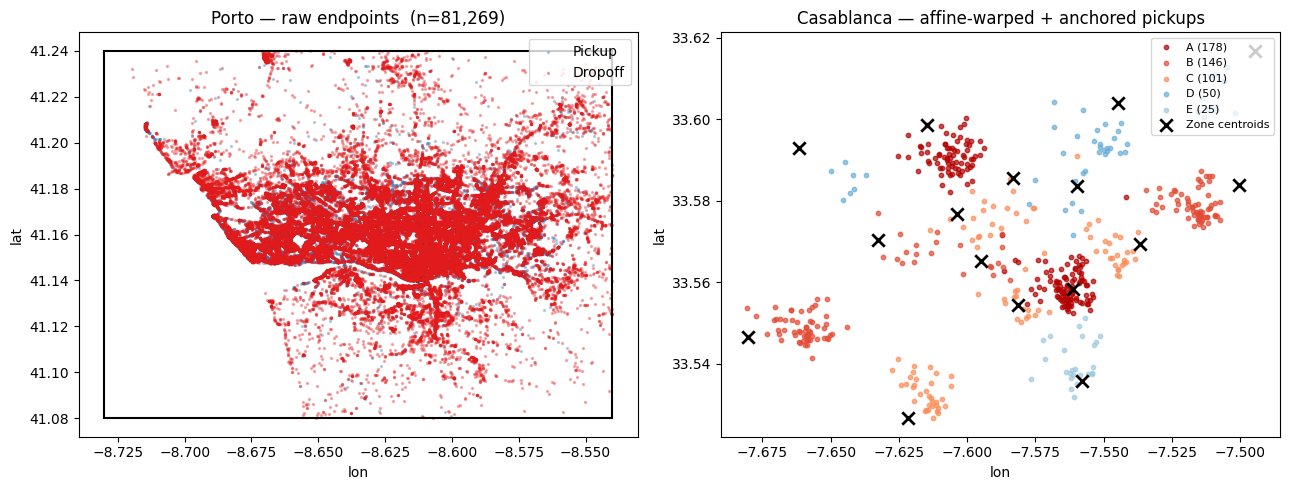

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

AE_COLORS_MPL = {'A':'#b30000','B':'#e34a33','C':'#fc8d59','D':'#6baed6','E':'#9ecae1'}

# =============== Plot 1 — Porto bbox → Casa bbox affine transform ================
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# Porto (left): raw endpoints
ax[0].scatter(porto_clean['lon_start'], porto_clean['lat_start'], s=2, alpha=0.3, c='#377eb8', label='Pickup')
ax[0].scatter(porto_clean['lon_end'],   porto_clean['lat_end'],   s=2, alpha=0.3, c='#e41a1c', label='Dropoff')
ax[0].add_patch(mpatches.Rectangle((PORTO_BBOX['lon_min'], PORTO_BBOX['lat_min']),
                                   PORTO_BBOX['lon_max']-PORTO_BBOX['lon_min'],
                                   PORTO_BBOX['lat_max']-PORTO_BBOX['lat_min'],
                                   fill=False, ec='black', lw=1.5))
ax[0].set_title(f'Porto — raw endpoints  (n={len(porto_clean):,})')
ax[0].set_xlabel('lon'); ax[0].set_ylabel('lat'); ax[0].legend(loc='upper right')

# Casa (right): anchored endpoints colored by AE class
for cls in 'ABCDE':
    s = sample_df[sample_df.origin_class == cls]
    ax[1].scatter(s['start_anc_lon'], s['start_anc_lat'], s=10, alpha=0.7,
                  c=AE_COLORS_MPL[cls], label=f'{cls} ({len(s)})')
# Zone centroids
ax[1].scatter(zone_map_df['centroid_lon'], zone_map_df['centroid_lat'],
              s=80, marker='x', c='black', lw=2, label='Zone centroids')
ax[1].set_title('Casablanca — affine-warped + anchored pickups')
ax[1].set_xlabel('lon'); ax[1].set_ylabel('lat'); ax[1].legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()


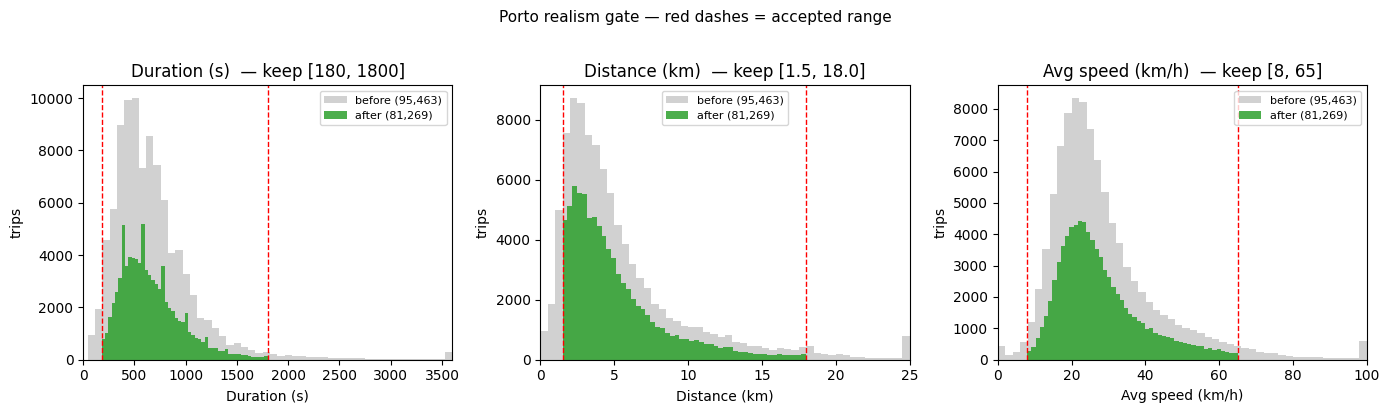

In [19]:
# =============== Plot 2 — Porto trip quality filter: before vs after ===============
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [('duration_s', 'Duration (s)', (0, 3600), [180, 1800]),
           ('distance_km', 'Distance (km)', (0, 25), [1.5, 18.0]),
           ('avg_speed_kmh', 'Avg speed (km/h)', (0, 100), [8, 65])]
for ax, (col, label, xlim, keep) in zip(axes, metrics):
    ax.hist(porto_df[col].clip(*xlim), bins=50, alpha=0.45, color='#999', label=f'before ({len(porto_df):,})')
    ax.hist(porto_clean[col].clip(*xlim), bins=50, alpha=0.85, color='#2ca02c', label=f'after ({len(porto_clean):,})')
    ax.axvline(keep[0], c='red', ls='--', lw=1); ax.axvline(keep[1], c='red', ls='--', lw=1)
    ax.set_xlabel(label); ax.set_ylabel('trips'); ax.set_xlim(*xlim); ax.legend(fontsize=8)
    ax.set_title(f'{label}  — keep [{keep[0]}, {keep[1]}]')
plt.suptitle('Porto realism gate — red dashes = accepted range', y=1.02, fontsize=11)
plt.tight_layout(); plt.show()


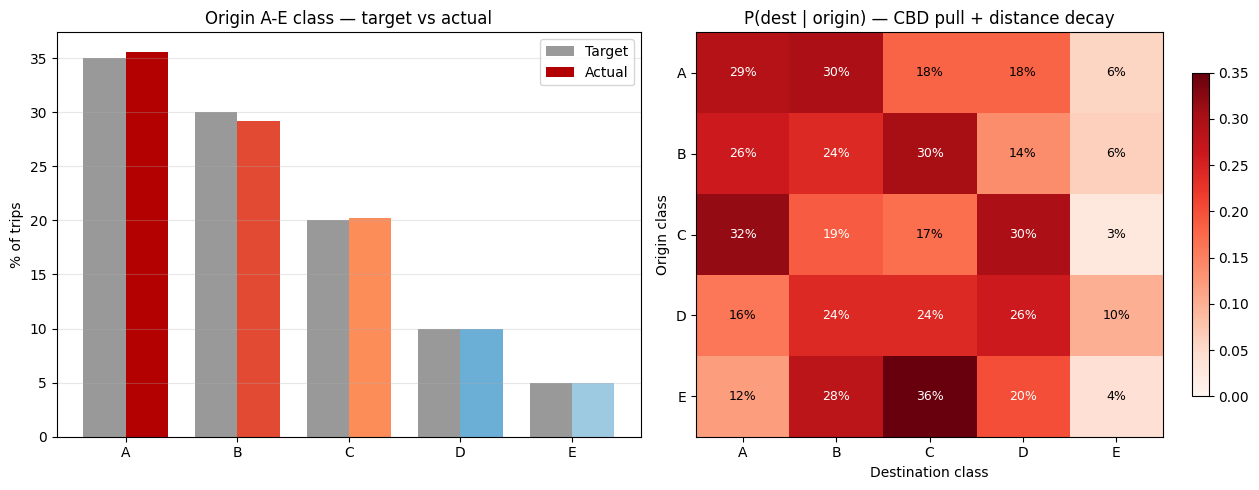

In [21]:
# =============== Plot 3 + 4 — A-E sampling validation + OD transition heatmap ===============
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 3 — origin class distribution (actual vs target)
target = pd.Series(AE_ORIGIN_P)
actual = sample_df['origin_class'].value_counts(normalize=True).reindex(list('ABCDE')).fillna(0)
x = np.arange(5); w = 0.38
axes[0].bar(x - w/2, target.values * 100, w, color='#999', label='Target')
axes[0].bar(x + w/2, actual.values * 100, w,
            color=[AE_COLORS_MPL[c] for c in 'ABCDE'], label='Actual')
axes[0].set_xticks(x); axes[0].set_xticklabels(list('ABCDE'))
axes[0].set_ylabel('% of trips'); axes[0].set_title('Origin A-E class — target vs actual')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Plot 4 — OD transition heatmap
ct = pd.crosstab(sample_df.origin_class, sample_df.dest_class, normalize='index').reindex(
    index=list('ABCDE'), columns=list('ABCDE')).fillna(0)
im = axes[1].imshow(ct.values, cmap='Reds', aspect='auto', vmin=0, vmax=0.35)
axes[1].set_xticks(range(5)); axes[1].set_xticklabels(list('ABCDE'))
axes[1].set_yticks(range(5)); axes[1].set_yticklabels(list('ABCDE'))
axes[1].set_xlabel('Destination class'); axes[1].set_ylabel('Origin class')
axes[1].set_title('P(dest | origin) — CBD pull + distance decay')
for i in range(5):
    for j in range(5):
        axes[1].text(j, i, f'{ct.values[i,j]*100:.0f}%',
                     ha='center', va='center', fontsize=9,
                     color='white' if ct.values[i,j] > 0.18 else 'black')
plt.colorbar(im, ax=axes[1], shrink=0.8)
plt.tight_layout(); plt.show()


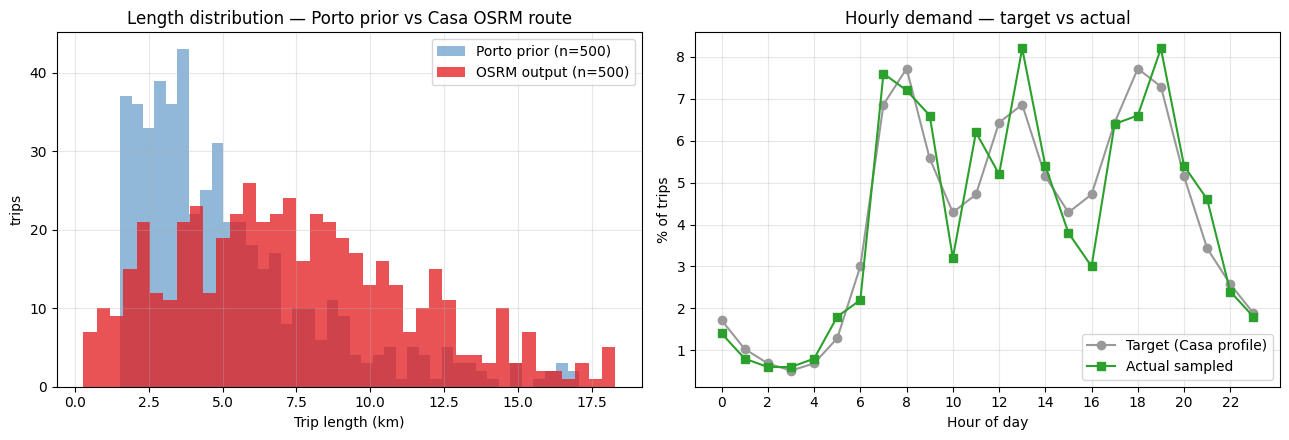

In [22]:
# =============== Plot 5 — Route length: Porto prior vs OSRM output ===============
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

porto_used_km = sample_df['distance_km']
osrm_km = trips['route_length_m'] / 1000.0

ax[0].hist(porto_used_km, bins=40, alpha=0.55, color='#377eb8', label=f'Porto prior (n={len(porto_used_km)})')
ax[0].hist(osrm_km,       bins=40, alpha=0.75, color='#e41a1c', label=f'OSRM output (n={len(osrm_km)})')
ax[0].set_xlabel('Trip length (km)'); ax[0].set_ylabel('trips')
ax[0].set_title('Length distribution — Porto prior vs Casa OSRM route')
ax[0].legend(); ax[0].grid(alpha=0.3)

# Hourly demand profile target vs actual
hr_target = CASA_HOURLY_WEIGHTS * 100
hr_actual = trips['hour'].value_counts(normalize=True).sort_index().reindex(range(24)).fillna(0).values * 100
ax[1].plot(range(24), hr_target, 'o-', color='#999', label='Target (Casa profile)')
ax[1].plot(range(24), hr_actual, 's-', color='#2ca02c', label='Actual sampled')
ax[1].set_xlabel('Hour of day'); ax[1].set_ylabel('% of trips')
ax[1].set_title('Hourly demand — target vs actual')
ax[1].set_xticks(range(0, 24, 2)); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


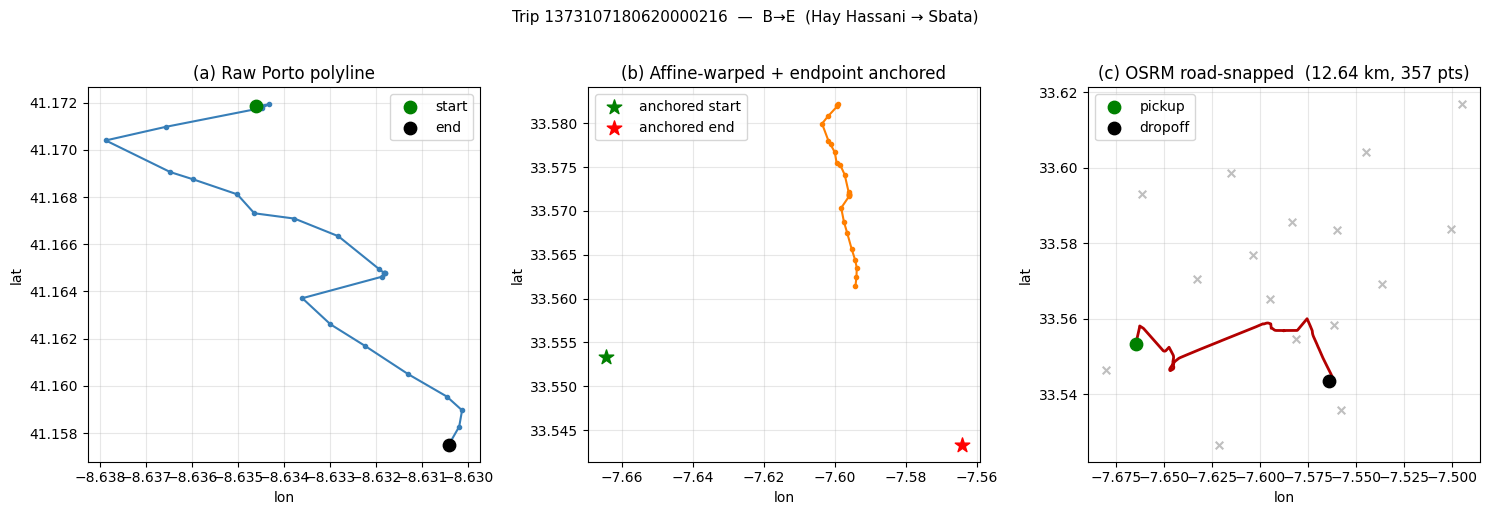


Summary of the 3 stages for this trip:
  Porto endpoints:  ([-8.634618, 41.171841]) -> ([-8.630424, 41.157504])
  After affine+anchor: (33.55335, -7.66462) -> (33.54333, -7.56415)
  After OSRM:       357 road points, 12.64 km, 16.4 min


In [23]:
# =============== Plot 6 — One trip: raw Porto → affine-warped → OSRM road-snapped ===
# Pick a trip where all three stages exist
demo = trips.iloc[0]
porto_pts = porto_clean.loc[porto_clean.TRIP_ID == demo.TRIP_ID, 'pts']
porto_pts = porto_pts.iloc[0] if len(porto_pts) else sample_df.iloc[0]['pts'] if 'pts' in sample_df.columns else None

# Reconstruct affine-warped polyline (endpoints only were anchored; we show full warp)
if porto_pts is not None:
    warped = [(lat * s_lat + t_lat, lon * s_lon + t_lon) for lon, lat in porto_pts]
else:
    warped = [(demo.start_lat, demo.start_lon), (demo.end_lat, demo.end_lon)]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# (a) Raw Porto polyline
if porto_pts is not None:
    pp = np.array(porto_pts)
    ax[0].plot(pp[:,0], pp[:,1], '-o', ms=3, color='#377eb8')
    ax[0].scatter([pp[0,0]], [pp[0,1]], s=80, c='green', zorder=5, label='start')
    ax[0].scatter([pp[-1,0]], [pp[-1,1]], s=80, c='black', zorder=5, label='end')
ax[0].set_title('(a) Raw Porto polyline')
ax[0].set_xlabel('lon'); ax[0].set_ylabel('lat'); ax[0].legend(); ax[0].grid(alpha=0.3)

# (b) Affine-warped into Casa bbox (before OSRM)
wp = np.array(warped)
ax[1].plot(wp[:,1], wp[:,0], '-o', ms=3, color='#ff7f00')
ax[1].scatter([demo.start_lon], [demo.start_lat], s=120, marker='*', c='green',
              zorder=5, label='anchored start')
ax[1].scatter([demo.end_lon], [demo.end_lat], s=120, marker='*', c='red',
              zorder=5, label='anchored end')
ax[1].set_title('(b) Affine-warped + endpoint anchored')
ax[1].set_xlabel('lon'); ax[1].set_ylabel('lat'); ax[1].legend(); ax[1].grid(alpha=0.3)

# (c) OSRM road-following polyline (the actual output)
rp = np.array(demo.route_latlon)
ax[2].plot(rp[:,1], rp[:,0], '-', lw=2, color='#b30000')
ax[2].scatter([rp[0,1]], [rp[0,0]], s=80, c='green', zorder=5, label='pickup')
ax[2].scatter([rp[-1,1]], [rp[-1,0]], s=80, c='black', zorder=5, label='dropoff')
# Overlay zone centroids for context
ax[2].scatter(zone_map_df['centroid_lon'], zone_map_df['centroid_lat'],
              s=30, marker='x', c='gray', alpha=0.5)
ax[2].set_title(f'(c) OSRM road-snapped  ({demo.route_length_m/1000:.2f} km, '
                f'{len(rp)} pts)')
ax[2].set_xlabel('lon'); ax[2].set_ylabel('lat'); ax[2].legend(); ax[2].grid(alpha=0.3)

plt.suptitle(f'Trip {demo.TRIP_ID}  —  {demo.origin_class}→{demo.dest_class}  '
             f'({zone_map_df.set_index("zone_id").loc[demo.origin_zone_id, "name"]} → '
             f'{zone_map_df.set_index("zone_id").loc[demo.dest_zone_id, "name"]})',
             y=1.02, fontsize=11)
plt.tight_layout(); plt.show()

print('\nSummary of the 3 stages for this trip:')
print(f'  Porto endpoints:  ({porto_pts[0] if porto_pts else "n/a"}) -> ({porto_pts[-1] if porto_pts else "n/a"})')
print(f'  After affine+anchor: ({demo.start_lat:.5f}, {demo.start_lon:.5f}) -> ({demo.end_lat:.5f}, {demo.end_lon:.5f})')
print(f'  After OSRM:       {len(rp)} road points, {demo.route_length_m/1000:.2f} km, '
      f'{demo.route_duration_s/60:.1f} min')
